# Deconvolution and iterative solvers

This example compares two inverse formulations using the same convolution operator.

We generate sparse reflectivity `x`, convolve it with a seismic wavelet, add noise, and recover the reflectivity using:

- damped least squares with `cgls`, and
- sparse $\ell_2-\ell_1$ inversion with `ista`.

The purpose is to show how the same MiniOps operator can be passed directly to different solvers.

In [1]:
using Pkg
Pkg.activate("..")

using MiniOps
using Random
using LinearAlgebra
using Printf
using CairoMakie
using SeisProcessing

  Activating project at `~/MiniOps`


## 1. Synthetic data and forward operator

In [7]:
Random.seed!(757)
dt = 0.002
w = seismic_wavelet(f0=34.0, dt=dt)

M = 200
Nspikes = 10
xtrue = zeros(M)
xtrue[randperm(M)[1:Nspikes]] = randn(Nspikes)

C = conv1d_op(w)
yclean = C * xtrue
y = yclean + 0.01 .* randn(size(yclean))

println("model length = ", length(xtrue))
println("data length  = ", length(y))
println("adjoint test = ", adjoint_test(C, randn(M), randn(length(y))))

model length = 200
data length  = 244
adjoint test = (true, 2.6130472214836936e-16)


## 2. Damped least-squares inversion

`cgls` solves a regularized least-squares problem using only applications of `C` and `C'`.

In [8]:
μ_l2 = 0.1
x_l2 = cgls(C, y, μ_l2, zeros(M); tol=1e-4, max_iter=240, verbose=true);


CGLS
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     2.293489e+00     2.630047e+00
      20     1.031587e-01     2.365934e-01     1.193815e-01
      38     1.030165e-01     2.362673e-01     1.193642e-01


## 3. Sparse inversion with ISTA

ISTA requires a stable step length. We estimate \(\|C\|\) with the power method and choose a step slightly below \(1/\|C\|^2\).

In [15]:
μ_l1 = 0.05
opn = opnorm_power(C, randn(M))
η = 0.98 / opn^2
x_l1 = ista(C, y, zeros(M), μ_l1, η; niter=1000, verbose=true);


ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     2.293489e+00     2.630047e+00
      20     1.821124e-01     4.176728e-01     3.999326e-01
      40     1.517859e-01     3.481193e-01     3.697382e-01
      60     1.417983e-01     3.252128e-01     3.569592e-01
      80     1.361583e-01     3.122775e-01     3.533378e-01
     100     1.338697e-01     3.070287e-01     3.514873e-01
     120     1.318803e-01     3.024661e-01     3.498529e-01
     140     1.301826e-01     2.985725e-01     3.483626e-01
     160     1.286460e-01     2.950483e-01     3.469911e-01
     180     1.272866e-01     2.919304e-01     3.458635e-01
     200     1.265907e-01     2.903345e-01     3.449678e-01
     220     1.260360e-01     2.890621e-01     3.441846e-01
     240     1.255249e-01     2.878901e-01     3.434836e-01
     260     1.250683e-01     2.868428e-01     3.428584e-01
     280     1.246971e-01     2.8

## 4. Compare the results

The curves are vertically shifted only to make the comparison readable.

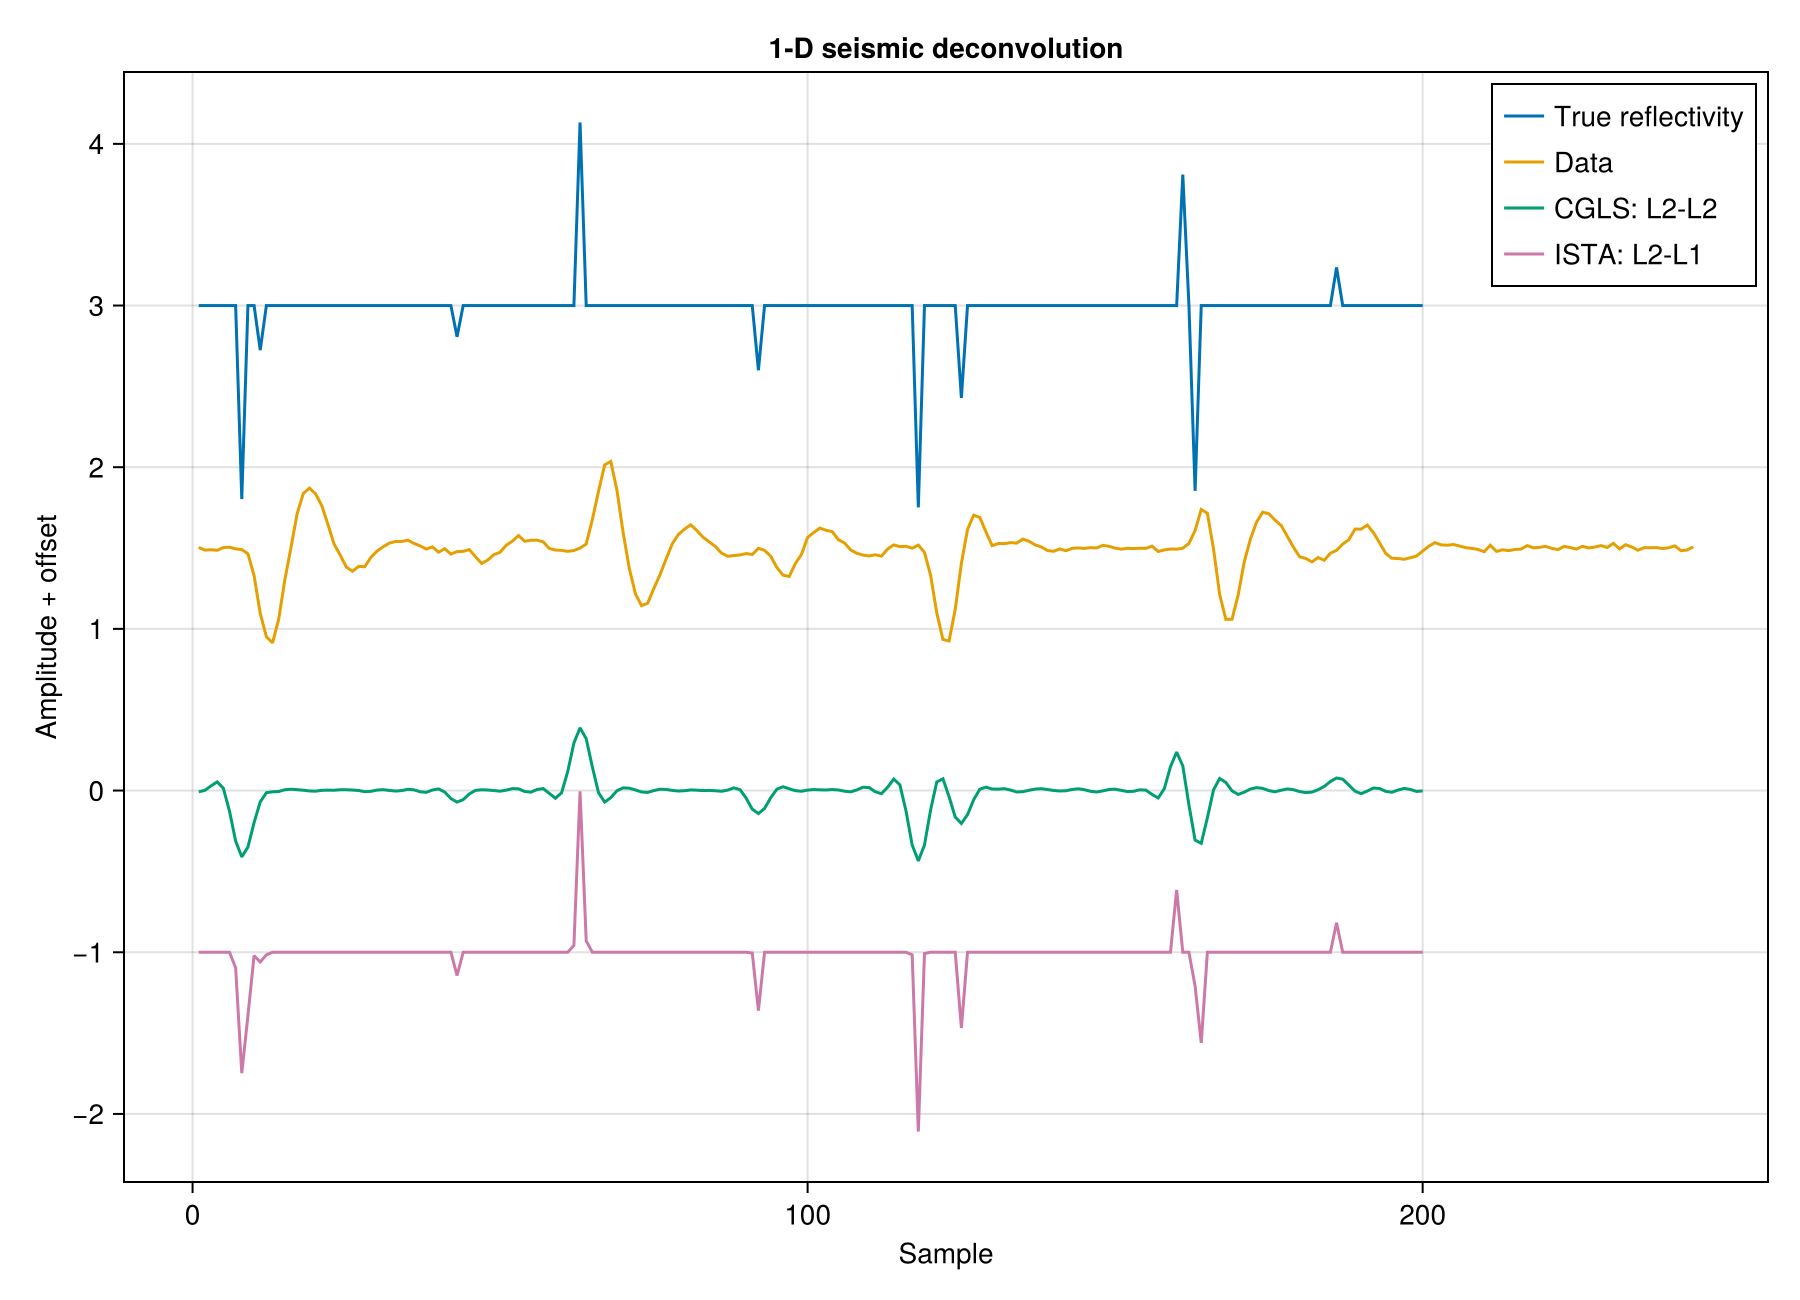

In [16]:
fig = Figure(size=(900,650))
ax = Axis(fig[1,1], xlabel="Sample", ylabel="Amplitude + offset",
          title="1-D seismic deconvolution")

lines!(ax, 1:M, xtrue .+ 3.0, label="True reflectivity")
lines!(ax, 1:length(y), y .+ 1.5, label="Data")
lines!(ax, 1:M, x_l2, label="CGLS: L2-L2")
lines!(ax, 1:M, x_l1 .- 1.0, label="ISTA: L2-L1")
axislegend(ax, position=:rt)
fig